In [ ]:
!pip install shap lime xgboost -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

sns.set_style("whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

100%|██████████| 41.0M/41.0M [00:00<00:00, 95.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1


In [ ]:
import pandas as pd

fake_df = pd.read_csv(f"{path}/Fake.csv")
true_df = pd.read_csv(f"{path}/True.csv")

fake_df['label'] = 0  # fake
true_df['label'] = 1  # real

df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(df.shape)
df.head()

(44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [ ]:
import os
print(os.listdir(path))

['Fake.csv', 'True.csv']


In [ ]:
df.tail()

,title,text,subject,date,label
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",0
44894,PM May seeks to ease Japan's Brexit fears duri...,LONDON/TOKYO (Reuters) - British Prime Ministe...,worldnews,"August 29, 2017",1
44895,Merkel: Difficult German coalition talks can r...,BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"November 16, 2017",1
44896,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",0
44897,BREAKING: HILLARY CLINTON’S STATE DEPARTMENT G...,IF SHE S NOT TOAST NOW THEN WE RE IN BIGGER TR...,politics,"Apr 23, 2015",0


In [ ]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


label
0    23481
1    21417
Name: count, dtype: int64


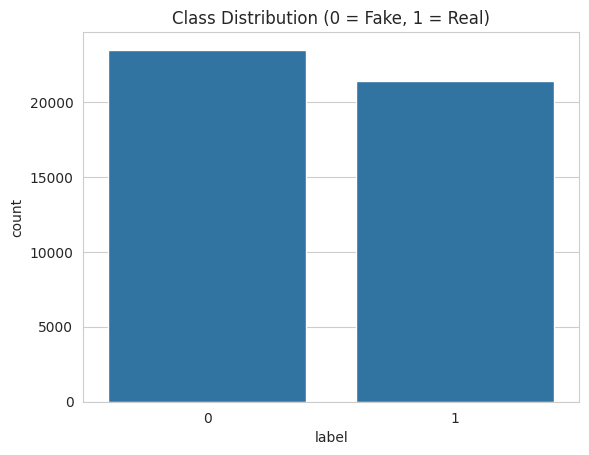

In [ ]:
print(df['label'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title('Class Distribution (0 = Fake, 1 = Real)')
plt.show()

In [ ]:
print(df.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


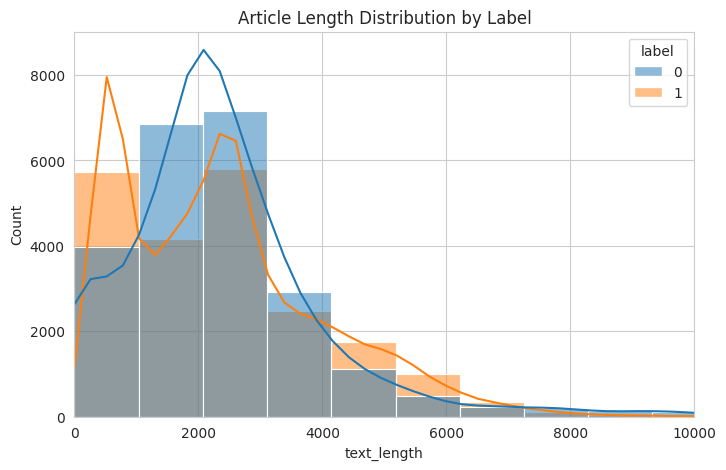

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,23481.0,2547.396235,2532.884399,1.0,1433.0,2166.0,3032.0,51794.0
1,21417.0,2383.278517,1684.835730,1.0,914.0,2222.0,3237.0,29781.0


In [ ]:
df['text_length'] = df['text'].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True)
plt.title('Article Length Distribution by Label')
plt.xlim(0, 10000)
plt.show()

df.groupby('label')['text_length'].describe()

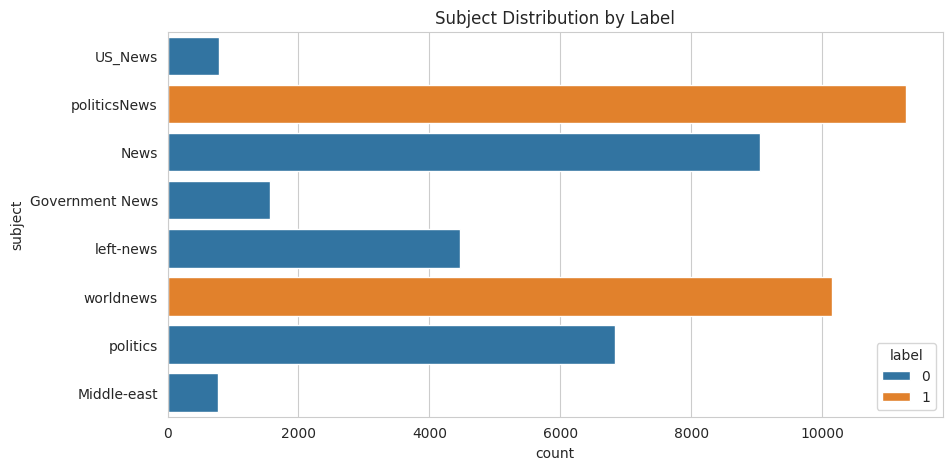

In [ ]:
if 'subject' in df.columns:
    plt.figure(figsize=(10,5))
    sns.countplot(y='subject', hue='label', data=df)
    plt.title('Subject Distribution by Label')
    plt.show()


In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

In [ ]:
df['content'] = df['title'].astype(str) + ' ' + df['text'].astype(str)
df['clean_content'] = df['content'].apply(clean_text)

df[['content', 'clean_content']].head()

,content,clean_content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call circuit court committed ‘coup d...
1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_content'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

print(X_train.shape, X_test.shape)

(35918,) (8980,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(35918, 5000) (8980, 5000)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

Logistic Regression
Accuracy: 0.9900890868596882
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)

print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, nb_preds))
print(classification_report(y_test, nb_preds))

Naive Bayes
Accuracy: 0.9468819599109132
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4696
           1       0.94      0.95      0.94      4284

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='logloss', random_state=42)
xgb.fit(X_train_tfidf, y_train)
xgb_preds = xgb.predict(X_test_tfidf)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))

XGBoost
Accuracy: 0.9983296213808464
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



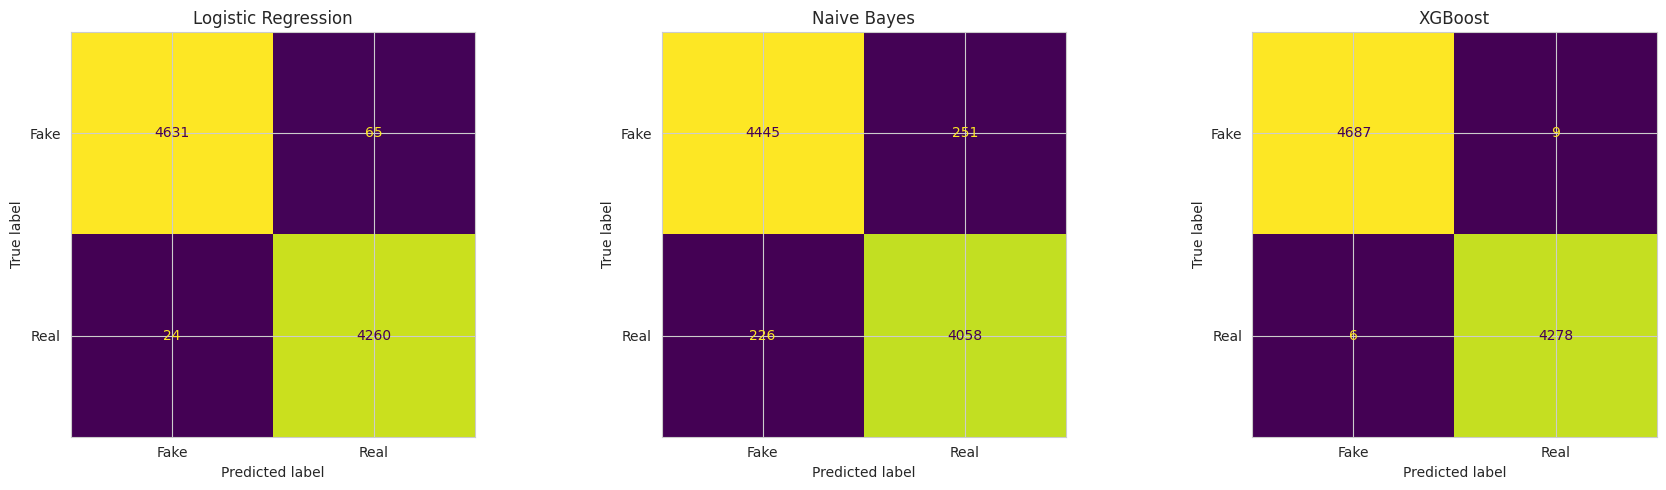

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, preds, name in zip(axes, [lr_preds, nb_preds, xgb_preds], ['Logistic Regression', 'Naive Bayes', 'XGBoost']):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Fake','Real']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [ ]:
import shap

# TF-IDF is sparse — convert a small sample to dense for SHAP
sample_size = 150
X_test_sample = X_test_tfidf[:sample_size]

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sample)

print(shap_values.shape)


(150, 5000)


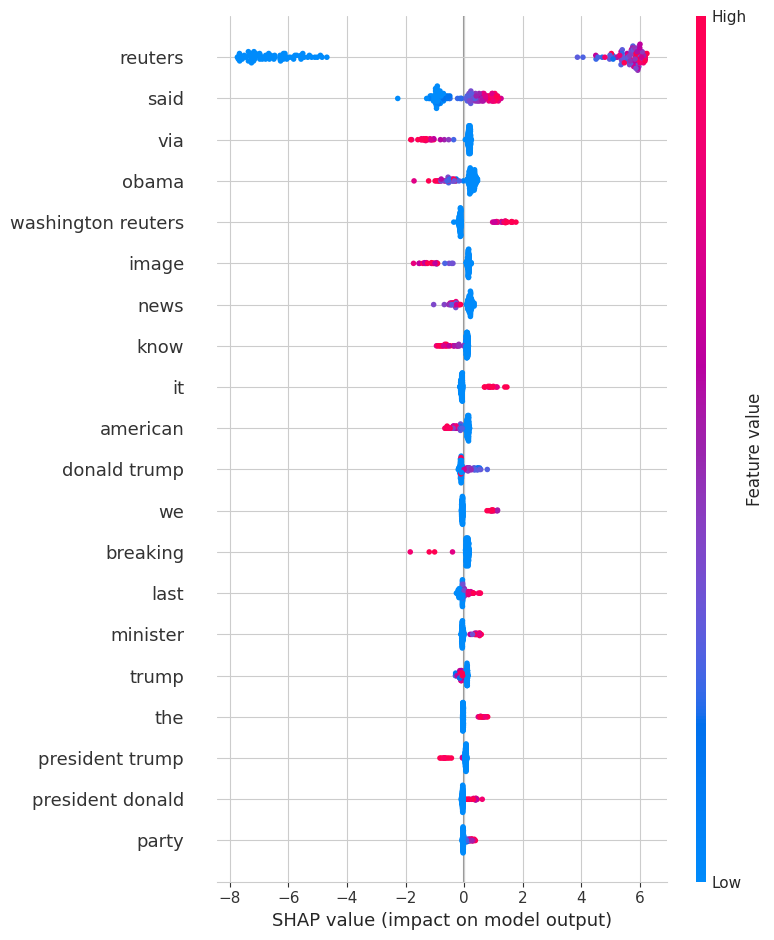

In [ ]:
feature_names = tfidf.get_feature_names_out()

X_test_sample_dense = X_test_sample.toarray()

shap.summary_plot(shap_values, X_test_sample_dense, feature_names=feature_names, max_display=20)

Actual label: 1 | Predicted: 1


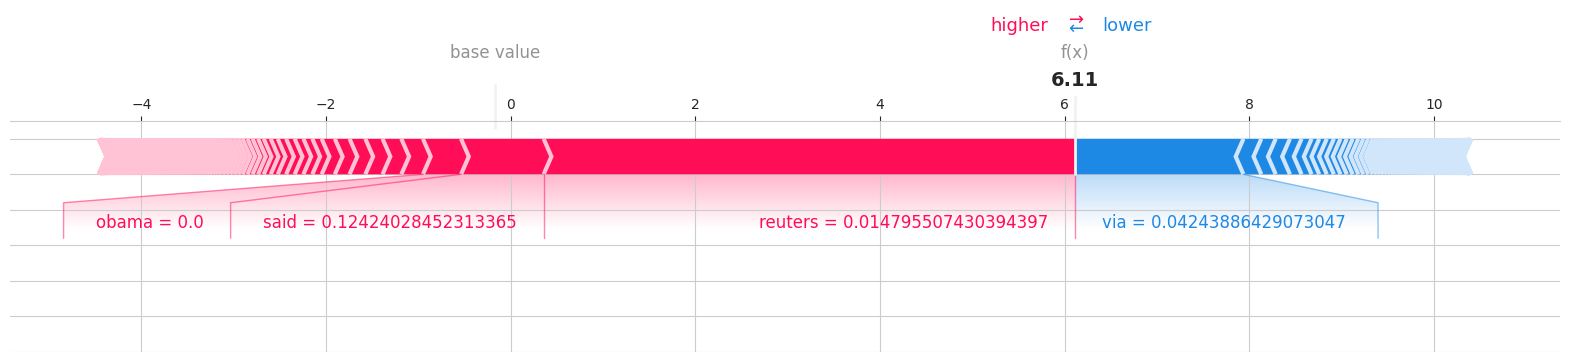

In [ ]:
idx = 0  # first sample in the test subset — change this to inspect different articles

print("Actual label:", y_test.iloc[idx], "| Predicted:", xgb_preds[idx])

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_sample_dense[idx],
    feature_names=feature_names,
    matplotlib=True
)

In [ ]:
import joblib

joblib.dump(xgb, 'fake_news_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

from google.colab import files
files.download('fake_news_model.pkl')
files.download('tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
xgb.save_model('fake_news_model.json')

from google.colab import files
files.download('fake_news_model.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>